
Target encoding
  MSE: 1.3332
  MAE: 0.8876
  R2: 0.5477

JOE-CHAR
  MSE: 0.4851
  MAE: 0.5523
  R2: 0.8354

Final learned category encodings
  A: 0.0423
  B: 0.6056
  C: 0.2663
  D: 0.8197
  E: 0.4353


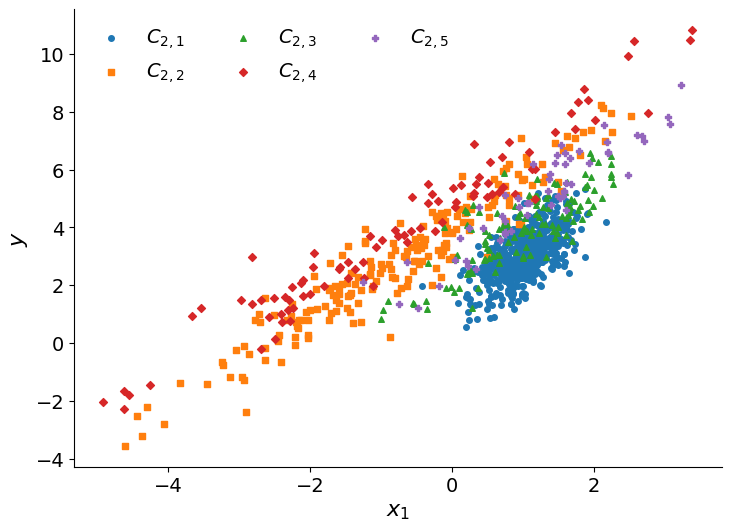

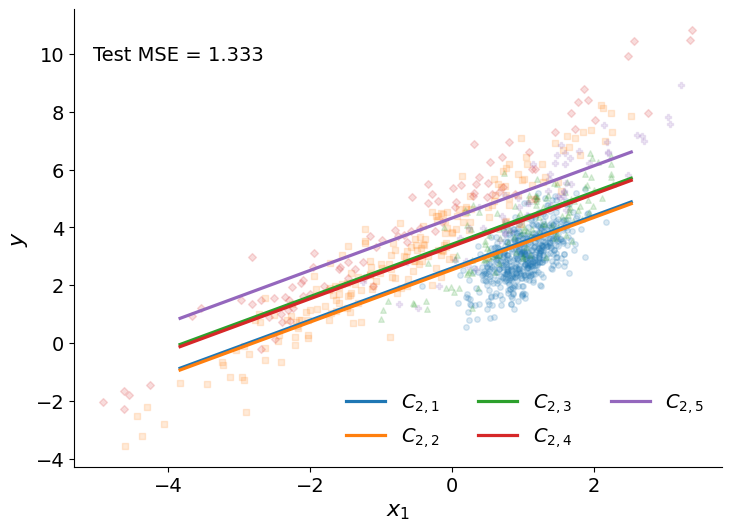

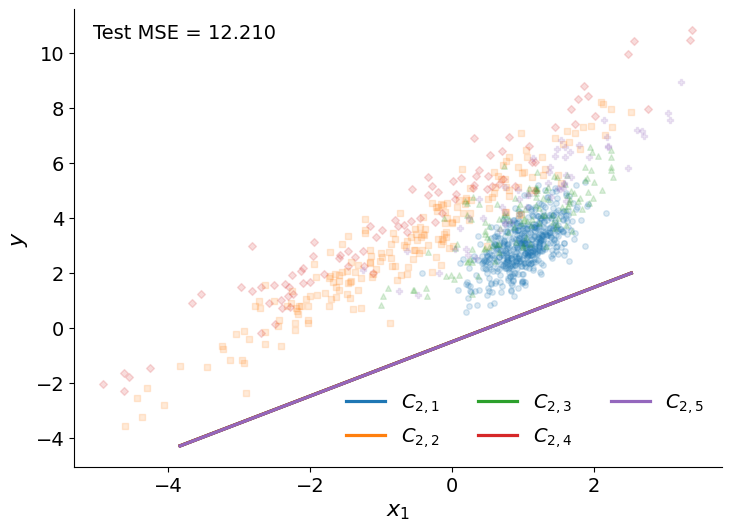

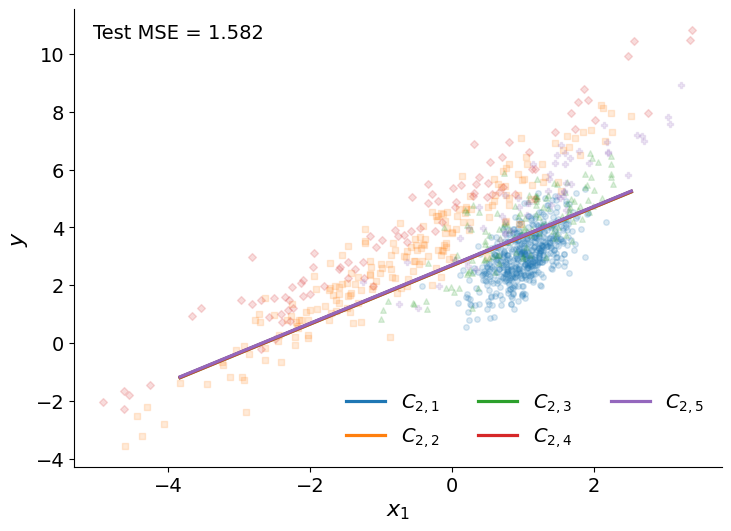

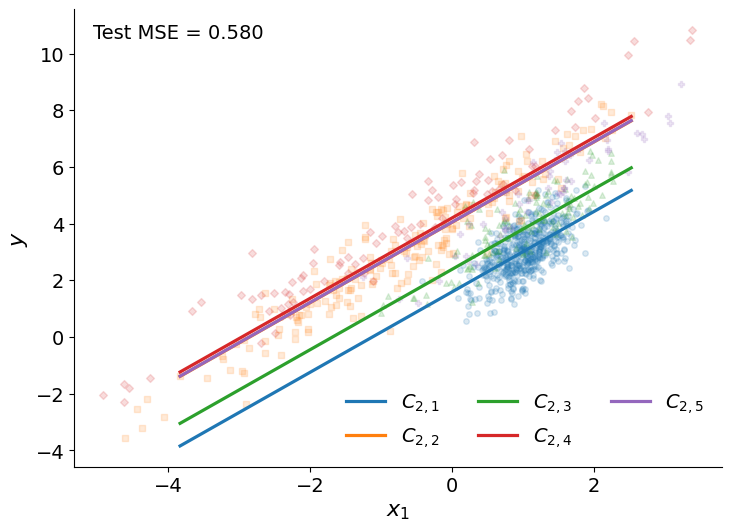

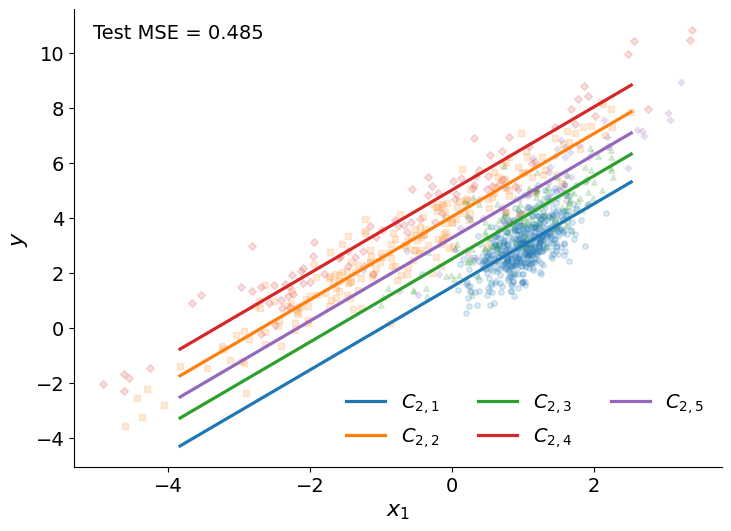

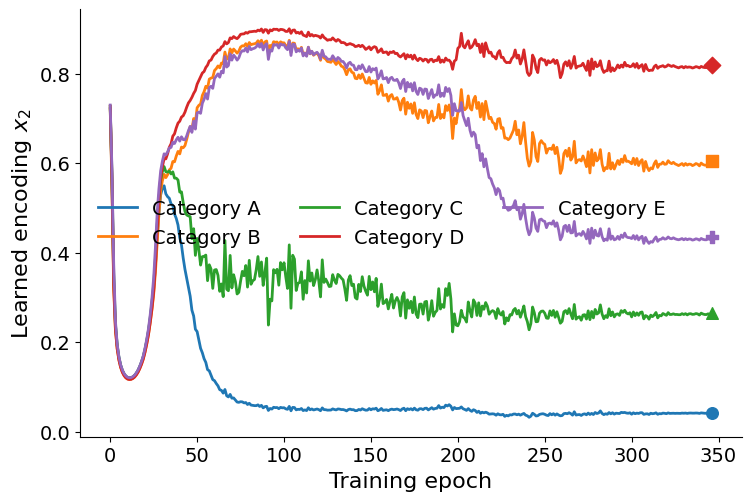

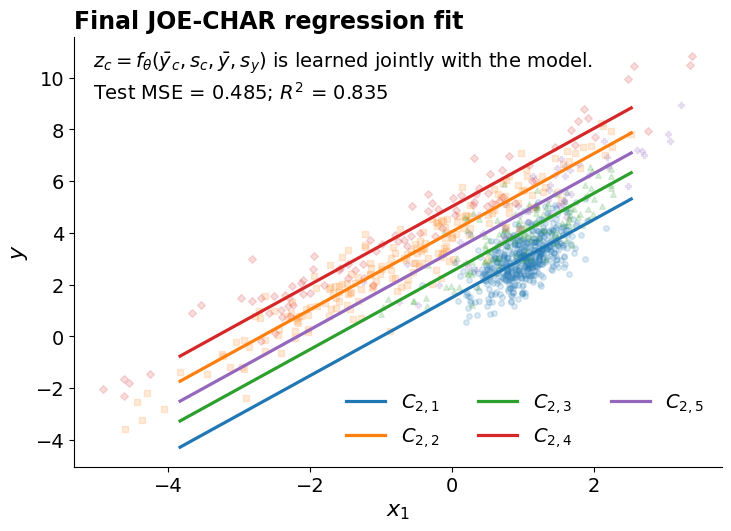

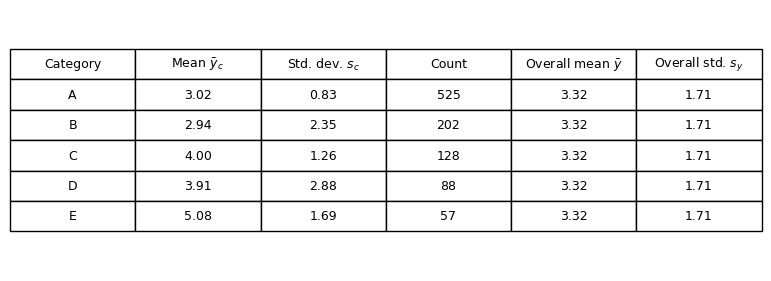

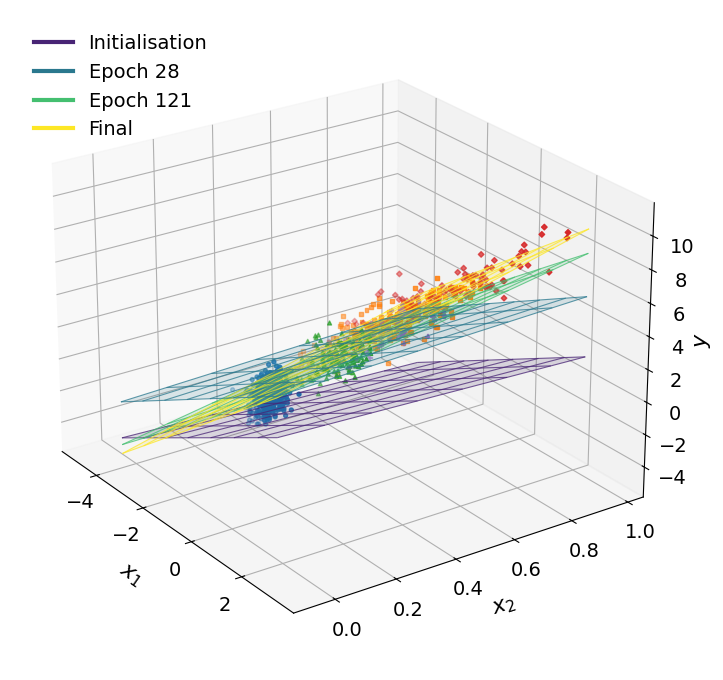

In [ ]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.layers import Layer, Dense, Input
from tensorflow.keras.models import Model


# setting of parameters


SEED = 4
N_TRAIN = 1000
N_TEST = 1000
BATCH_SIZE = 32
MAX_EPOCHS = 400

CATEGORIES = ("A", "B", "C", "D", "E")
CATEGORY_PROBABILITIES = (0.55, 0.20, 0.12, 0.08, 0.05) # frequency
MARKERS = {"A": "o", "B": "s", "C": "^", "D": "D", "E": "P"}

# nonlinear JOE-CHAR regression
ENCODER_VARIANT = "sigmoid"
OUTPUT_DIR = Path.cwd()

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# style for plots

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})



# defining the layers for JOE

class MyLayer(Layer):
    def call(self, small_models_outputs, inputs):
        return tf.concat(
            [*small_models_outputs.values(), inputs["rest"]],
            axis=-1,
        )


class SmallNetwork(Layer):
    def __init__(self, units, activation="sigmoid", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = activation
        self.dense_layers = []

    def build(self, input_shape):
        input_dim = int(input_shape[-1])

        for layer_index, number_of_units in enumerate(self.units):
            dense_layer = Dense(
                units=number_of_units,
                activation=self.activation,
                kernel_initializer="zeros",
                bias_initializer="zeros",
                name=f"encoder_dense_{layer_index}",
            )

            dense_layer.build((None, input_dim))

            # Initialise every weight to zero
            initial_kernel = np.zeros(
                (input_dim, number_of_units),
                dtype=np.float32,
            )

            initial_kernel[0, 0] = 1.0

            initial_bias = np.zeros(
                number_of_units,
                dtype=np.float32,
            )

            dense_layer.set_weights(
                [initial_kernel, initial_bias]
            )

            self.dense_layers.append(dense_layer)
            input_dim = number_of_units

        super().build(input_shape)

    def call(self, inputs):
        h = inputs

        for dense_layer in self.dense_layers:
            h = dense_layer(h)

        return h




# simulating the data that is more challenging for target (data is simulated as regression)

def simulate_regression_data(n, seed):

    rng = np.random.default_rng(seed)

    x2 = rng.choice(
        CATEGORIES,
        size=n,
        p=CATEGORY_PROBABILITIES,
    )

    # this is the effect of each category in the linear combination
    category_effect = {
        "A": -1.5,
        "B": 1.0,
        "C": -0.5,
        "D": 2.0,
        "E": 0.3,
    }

    # mean for generating each category
    x1_mean = {
        "A": 1.00,
        "B": -0.67,
        "C": 1.00,
        "D": -0.67,
        "E": 1.15,
    }

    #std for generating each category
    x1_std = {
        "A": 0.35,
        "B": 1.45,
        "C": 0.75,
        "D": 1.90,
        "E": 1.10,
    }

    # noise (prob not used)
    noise_std = {
        "A": 0.35,
        "B": 0.85,
        "C": 0.55,
        "D": 1.10,
        "E": 0.75,
    }

    x1 = np.empty(n)
    y = np.empty(n)

    for category in CATEGORIES:
        mask = x2 == category
        n_category = int(mask.sum())

        x1[mask] = rng.normal(
            x1_mean[category],
            x1_std[category],
            n_category,
        )

        y[mask] = (
            3.0
            + 1.5 * x1[mask]
            + category_effect[category]
            # + rng.normal(0.0, noise_std[category], n_category)
            + rng.normal(0.0, 0.7, n_category)
        )

    return pd.DataFrame({"x1": x1, "x2": x2, "y": y})



# category characteristics to use as input in joe-char
def calculate_category_characteristics(train_df):
    overall_mean = float(train_df["y"].mean())
    overall_std = float(train_df["y"].std(ddof=0))

    summary = (
        train_df.groupby("x2", observed=True)["y"]
        .agg(mean="mean", std=lambda s: s.std(ddof=0), count="count")
        .reindex(CATEGORIES)
        .reset_index()
    )

    summary["std"] = summary["std"].fillna(0.0)
    summary["overall_mean"] = overall_mean
    summary["overall_std"] = overall_std
    return summary


def map_characteristics_to_rows(df, summary):
    lookup = summary.set_index("x2")
    result = df.copy()
    result["cat_mean"] = result["x2"].map(lookup["mean"]).astype(float)
    result["cat_std"] = result["x2"].map(lookup["std"]).astype(float)
    result["overall_mean"] = result["x2"].map(lookup["overall_mean"]).astype(float)
    result["overall_std"] = result["x2"].map(lookup["overall_std"]).astype(float)
    return result


def make_dataset(df, shuffle):
    characteristics = df[
        ["cat_mean", "cat_std", "overall_mean", "overall_std"]
    ].to_numpy(dtype=np.float32)
    rest = df[["x1"]].to_numpy(dtype=np.float32)
    target = df["y"].to_numpy(dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        ({"x2": characteristics, "rest": rest}, target)
    )

    if shuffle:
        dataset = dataset.shuffle(
            len(df),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# target
def fit_target_encoding(train_df, test_df, summary):
    lookup = summary.set_index("x2")["mean"]
    prior = float(train_df["y"].mean())

    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    train_encoded["target_mean"] = train_encoded["x2"].map(lookup).fillna(prior)
    test_encoded["target_mean"] = test_encoded["x2"].map(lookup).fillna(prior)

    features = ["target_mean", "x1"]
    model = LinearRegression().fit(train_encoded[features], train_encoded["y"])
    predictions = model.predict(test_encoded[features])

    metrics = regression_metrics(test_encoded["y"], predictions)
    return model, metrics


def target_prediction_lines(model, summary, x_grid):
    lines = {}
    for _, row in summary.iterrows():
        design = pd.DataFrame(
            {
                "target_mean": np.full(len(x_grid), row["mean"]),
                "x1": x_grid,
            }
        )
        lines[row["x2"]] = model.predict(design)
    return lines


# joe-char

def plot_data_only(train_df):
    figure, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)

    for category in CATEGORIES:
        subset = train_df[train_df["x2"] == category]
        ax.scatter(
            subset["x1"],
            subset["y"],
            s=16,
            marker=MARKERS[category],
            label=rf"$C_{{2,{CATEGORIES.index(category)+1}}}$",
        )

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$y$")
    apply_axis_style(ax)
    ax.legend(frameon=False, ncol=3)

    save_figure(figure, "00_data_only")
    return figure

def build_joe_char_regression():
    characteristic_input = Input(shape=(4,), name="x2")
    continuous_input = Input(shape=(1,), name="rest")

    if ENCODER_VARIANT == "sigmoid":
        encoder = SmallNetwork([3, 1], "sigmoid", name="joe_char_encoder")
    elif ENCODER_VARIANT == "linear":
        encoder = SmallNetwork([1], "linear", name="joe_char_encoder")


    encoded = encoder(characteristic_input)
    joined = MyLayer()(
        {"x2": encoded},
        {"x2": characteristic_input, "rest": continuous_input},
    )

    output = Dense(
        1,
        activation="linear",
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=50),
        name="prediction",
    )(joined)

    model = Model(
        inputs={"x2": characteristic_input, "rest": continuous_input},
        outputs=output,
        name="JOE_CHAR_REGRESSION",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
        loss="mean_squared_error",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model, encoder


def characteristic_matrix(summary):
    return summary[
        ["mean", "std", "overall_mean", "overall_std"]
    ].to_numpy(dtype=np.float32)


def get_encoder_outputs(encoder, summary):
    values = encoder(
        tf.constant(characteristic_matrix(summary)),
        training=False,
    ).numpy().reshape(-1)
    return dict(zip(CATEGORIES, values))


def get_prediction_parameters(model):
    weights, bias = model.get_layer("prediction").get_weights()
    return {
        "gamma": float(weights[0, 0]),
        "beta1": float(weights[1, 0]),
        "beta0": float(bias[0]),
    }


def get_learned_encodings(encoder, summary):
    """Return the raw scalar output z_c of the JOE-CHAR encoder."""
    return get_encoder_outputs(encoder, summary)


def joe_prediction_lines(model, summary, x_grid):
    lines = {}
    for _, row in summary.iterrows():
        characteristics = np.tile(
            np.array(
                [
                    row["mean"],
                    row["std"],
                    row["overall_mean"],
                    row["overall_std"],
                ],
                dtype=np.float32,
            ),
            (len(x_grid), 1),
        )
        inputs = {
            "x2": characteristics,
            "rest": x_grid.reshape(-1, 1).astype(np.float32),
        }
        lines[row["x2"]] = model.predict(inputs, verbose=0).reshape(-1)
    return lines


class ProgressRecorder(tf.keras.callbacks.Callback):

    def __init__(self, encoder, summary, x_grid):
        super().__init__()
        self.encoder = encoder
        self.summary = summary
        self.x_grid = x_grid
        self.snapshots = []

    def _capture(self, epoch, logs=None, label=None):
        logs = logs or {}
        self.snapshots.append(
            {
                "epoch": int(epoch),
                "label": label,
                "loss": float(logs.get("loss", np.nan)),
                "val_loss": float(logs.get("val_loss", np.nan)),
                "lines": joe_prediction_lines(self.model, self.summary, self.x_grid),
                "encodings": get_learned_encodings(
                    self.encoder,
                    self.summary,
                ),
                "parameters": get_prediction_parameters(self.model),
            }
        )

    def on_train_begin(self, logs=None):
        self._capture(epoch=0, logs=logs, label="Initialisation")

    def on_epoch_end(self, epoch, logs=None):
        self._capture(epoch=epoch + 1, logs=logs)

    def capture_restored_model(self):
        self._capture(
            epoch=self.snapshots[-1]["epoch"],
            logs={},
            label="Final",
        )


# comparison metrics

def regression_metrics(y_true, y_pred):
    return {
        "mse": mean_squared_error(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def evaluate_joe(model, test_dataset, y_test):
    predictions = model.predict(test_dataset, verbose=0).reshape(-1)
    return regression_metrics(y_test, predictions)



# plotting details

def apply_axis_style(ax):
    # ax.grid(alpha=0.16)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_data_and_lines(ax, data, lines, x_grid, show_legend=True):
    for category in CATEGORIES:
        subset = data[data["x2"] == category]
        ax.scatter(
            subset["x1"],
            subset["y"],
            s=16,
            alpha=0.16,
            marker=MARKERS[category],
        )
        ax.plot(
            x_grid,
            lines[category],
            linewidth=2.3,
            label=rf"$C_{{2,{CATEGORIES.index(category)+1}}}$",
        )

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$y$")
    apply_axis_style(ax)
    if show_legend:
        ax.legend(frameon=False, ncol=3)


# function to save figure
def save_figure(figure, stem):
    for extension in ("pdf", "svg", "png"):
        path = OUTPUT_DIR / f"{stem}.{extension}"
        kwargs = {"bbox_inches": "tight"}
        if extension == "png":
            kwargs["dpi"] = 300
        figure.savefig(path, **kwargs)


# Separate figures


def plot_target_fit(train_df, target_lines, x_grid, metrics):
    figure, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)
    draw_data_and_lines(ax, train_df, target_lines, x_grid)
    # ax.set_title("Target encoding followed by regression", loc="left", fontweight="bold")
    ax.text(
        0.03,
        0.97,
        # r"Each category is replaced by its training mean $\bar y_c$."
        f"\nTest MSE = {metrics['mse']:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
    )


    save_figure(figure, "01_target_encoding_fit")
    return figure


def choose_progress_snapshots(snapshots):
    regular = [s for s in snapshots if s.get("label") != "Selected final model"]
    final = snapshots[-1]
    maximum_epoch = max(s["epoch"] for s in regular)

    desired = [0, max(1, round(0.08 * maximum_epoch)), max(2, round(0.35 * maximum_epoch))]
    selected = []
    for target_epoch in desired:
        selected.append(min(regular, key=lambda s: abs(s["epoch"] - target_epoch)))
    selected.append(final)

    # Avoid accidental duplicate panels in very short training runs.
    output = []
    seen = set()
    for snapshot in selected:
        key = (snapshot["epoch"], snapshot.get("label"))
        if key not in seen:
            output.append(snapshot)
            seen.add(key)
    while len(output) < 4:
        candidate = regular[min(len(regular) - 1, len(output))]
        output.insert(-1, candidate)
    return output[:4]




def plot_joe_progression(train_df, test_df, snapshots, x_grid):
    selected = choose_progress_snapshots(snapshots)
    figures = []

    legend_labels = [
        r"$C_{2,1}$",
        r"$C_{2,2}$",
        r"$C_{2,3}$",
        r"$C_{2,4}$",
        r"$C_{2,5}$",
    ]

    for index, snapshot in enumerate(selected):
        figure, ax = plt.subplots(
            figsize=(7.2, 5.2),
            constrained_layout=True,
        )

        draw_data_and_lines(
            ax,
            train_df,
            snapshot["lines"],
            x_grid,
            show_legend=False,
        )

        # Calculate the test predictions using the model parameters
        # and category encodings at this exact iteration
        parameters = snapshot["parameters"]
        encodings = snapshot["encodings"]

        test_predictions = (
            parameters["beta0"]
            + parameters["beta1"] * test_df["x1"].to_numpy()
            + parameters["gamma"]
            * test_df["x2"].map(encodings).to_numpy()
        )

        test_mse = mean_squared_error(
            test_df["y"].to_numpy(),
            test_predictions,
        )

        label = snapshot.get("label") or f"Epoch {snapshot['epoch']}"

        # ax.set_title(
        #     label,
        #     loc="left",
        #     fontweight="bold",
        # )

        ax.text(
            0.03,
            0.97,
            f"Test MSE = {test_mse:.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
        )

        handles, _ = ax.get_legend_handles_labels()

        ax.legend(
            handles,
            legend_labels,
            frameon=False,
            ncol=3,
            loc="lower right",
        )

        save_figure(
            figure,
            f"02_joe_char_progression_{index + 1}",
        )

        figures.append(figure)

    return figures


def plot_encoding_progression(snapshots):
    regular = [s for s in snapshots if s.get("label") != "Selected final model"]
    final = snapshots[-1]

    figure, ax = plt.subplots(figsize=(7.4, 4.9), constrained_layout=True)

    epochs = [s["epoch"] for s in regular]
    for category in CATEGORIES:
        values = [s["encodings"][category] for s in regular]
        ax.plot(
            epochs,
            values,
            linewidth=2.0,
            label=f"Category {category}",
        )
        ax.scatter(
            [epochs[-1]],
            [final["encodings"][category]],
            s=70,
            marker=MARKERS[category],
            zorder=3,
        )

    # ax.set_title(
    #     "JOE-CHAR encodings during optimisation",
    #     loc="left",
    #     fontweight="bold",
    # )
    ax.set_xlabel("Training epoch")
    ax.set_ylabel(r"Learned encoding $x_2$")
    ax.legend(frameon=False, ncol=3)
    apply_axis_style(ax)
    save_figure(figure, "03_encoding_progression")
    return figure


def plot_final_joe_fit(train_df, final_lines, x_grid, metrics):
    figure, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)
    draw_data_and_lines(ax, train_df, final_lines, x_grid)
    ax.set_title("Final JOE-CHAR regression fit", loc="left", fontweight="bold")
    ax.text(
        0.03,
        0.97,
        r"$z_c=f_\theta(\bar y_c,s_c,\bar y,s_y)$ is learned jointly with the model."
        f"\nTest MSE = {metrics['mse']:.3f}; $R^2$ = {metrics['r2']:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
    )
    save_figure(figure, "04_final_joe_char_fit")
    return figure


def plot_characteristics(summary):
    figure, ax = plt.subplots(figsize=(7.6, 2.7), constrained_layout=True)
    ax.axis("off")
    # ax.set_title(
    #     "Category characteristics supplied to JOE-CHAR",
    #     loc="left",
    #     fontweight="bold",
    # )

    rows = [
        [
            row["x2"],
            f'{row["mean"]:.2f}',
            f'{row["std"]:.2f}',
            f'{int(row["count"])}',
            f'{row["overall_mean"]:.2f}',
            f'{row["overall_std"]:.2f}',
        ]
        for _, row in summary.iterrows()
    ]

    table = ax.table(
        cellText=rows,
        colLabels=[
            "Category",
            r"Mean $\bar y_c$",
            r"Std. dev. $s_c$",
            "Count",
            r"Overall mean $\bar y$",
            r"Overall std. $s_y$",
        ],
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.45)
    save_figure(figure, "05_category_characteristics")
    return figure

from mpl_toolkits.mplot3d import Axes3D  #3d plane evolution


def plot_joe_3d_progression(train_df, snapshots, x_grid):

    selected = choose_progress_snapshots(snapshots)

    figure = plt.figure(figsize=(10.5, 7.5))
    ax = figure.add_subplot(111, projection="3d")


    ax.set_position([0.06, 0.06, 0.82, 0.88])

    # Common axis ranges

    x_min = float(train_df["x1"].quantile(0.01))
    x_max = float(train_df["x1"].quantile(0.99))

    all_encodings = np.array(
        [
            snapshot["encodings"][category]
            for snapshot in selected
            for category in CATEGORIES
        ],
        dtype=float,
    )

    encoding_min = float(all_encodings.min())
    encoding_max = float(all_encodings.max())

    encoding_padding = max(
        0.03,
        0.12 * (encoding_max - encoding_min),
    )

    encoding_low = encoding_min - encoding_padding
    encoding_high = encoding_max + encoding_padding

    plane_x = np.linspace(x_min, x_max, 35)
    plane_z = np.linspace(encoding_low, encoding_high, 35)

    X1, Z = np.meshgrid(plane_x, plane_z)

    # Colours

    colours = plt.cm.viridis(
        np.linspace(0.1, 1.0, len(selected))
    )

    legend_handles = []

    category_colours = {
        "A": "tab:blue",
        "B": "tab:orange",
        "C": "tab:green",
        "D": "tab:red",
        "E": "tab:purple",
    }

    # Plot training data
    final_encodings = selected[-1]["encodings"]

    for category in CATEGORIES:
        subset = train_df[train_df["x2"] == category]

        ax.scatter(
            subset["x1"],
            np.full(
                len(subset),
                final_encodings[category]
            ),
            subset["y"],
            color=category_colours[category],
            marker=MARKERS[category],
            s=8,
        )

    # Plot optimisation planes

    for colour, snapshot in zip(colours, selected):
        parameters = snapshot["parameters"]

        Y_hat = (
            parameters["beta0"]
            + parameters["beta1"] * X1
            + parameters["gamma"] * Z
        )

        ax.plot_surface(
            X1,
            Z,
            Y_hat,
            color=colour,
            alpha=0.15,
            linewidth=0,
            antialiased=True,
        )

        ax.plot_wireframe(
            X1,
            Z,
            Y_hat,
            color=colour,
            rstride=5,
            cstride=5,
            linewidth=0.8,
            alpha=0.75,
        )

        label = (
            snapshot.get("label")
            or f"Epoch {snapshot['epoch']}"
        )

        legend_handles.append(
            plt.Line2D(
                [0],
                [0],
                color=colour,
                linewidth=3,
                label=label,
            )
        )


    ax.set_xlabel(
        r"$x_1$",
        labelpad=8,
    )

    ax.set_ylabel(
        r"$x_2$",
        labelpad=8,
    )

    ax.set_zlabel("")

    ax.text2D(
        1.05,
        0.50,
        r"$y$",
        transform=ax.transAxes,
        fontsize=16,
        ha="center",
        va="center",
        rotation=90,
    )


    ax.legend(
        handles=legend_handles,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
    )

    ax.view_init(
        elev=24,
        azim=-35,
    )

    # Save

    save_figure(
        figure,
        "07_joe_char_3d_plane_progression",
    )

    return figure




# def plot_joe_3d_progression(train_df, snapshots, x_grid):
#     """Plot four selected stages, emphasising how the fitted plane changes."""
#     selected = choose_progress_snapshots(snapshots)

#     figure = plt.figure(
#         figsize=(12.4, 9.2),
#         constrained_layout=True,
#     )

#     # Fixed x1 and encoding ranges across all panels.
#     x_min = float(train_df["x1"].quantile(0.01))
#     x_max = float(train_df["x1"].quantile(0.99))

#     all_encodings = np.array(
#         [
#             snapshot["encodings"][category]
#             for snapshot in selected
#             for category in CATEGORIES
#         ],
#         dtype=float,
#     )

#     encoding_min = float(all_encodings.min())
#     encoding_max = float(all_encodings.max())
#     encoding_padding = max(
#         0.03,
#         0.12 * (encoding_max - encoding_min),
#     )
#     encoding_low = encoding_min - encoding_padding
#     encoding_high = encoding_max + encoding_padding

#     # A moderately coarse mesh makes the changing tilt easy to see.
#     plane_x = np.linspace(x_min, x_max, 35)
#     plane_z = np.linspace(encoding_low, encoding_high, 35)
#     X1, Z = np.meshgrid(plane_x, plane_z)

#     # Compute common response limits from both the observations and all planes.
#     plane_values = []
#     for snapshot in selected:
#         parameters = snapshot["parameters"]
#         plane_values.append(
#             parameters["beta0"]
#             + parameters["beta1"] * X1
#             + parameters["gamma"] * Z
#         )

#     observed_low = float(train_df["y"].quantile(0.01))
#     observed_high = float(train_df["y"].quantile(0.99))
#     plane_low = min(float(values.min()) for values in plane_values)
#     plane_high = max(float(values.max()) for values in plane_values)

#     response_low = min(observed_low, plane_low)
#     response_high = max(observed_high, plane_high)
#     response_padding = 0.08 * (response_high - response_low)

#     legend_handles = None
#     legend_labels = None

#     for index, (snapshot, Y_hat) in enumerate(zip(selected, plane_values)):
#         ax = figure.add_subplot(
#             2,
#             2,
#             index + 1,
#             projection="3d",
#         )

#         encodings = snapshot["encodings"]
#         parameters = snapshot["parameters"]

#         # The fitted plane is the main object in this figure.
#         ax.plot_surface(
#             X1,
#             Z,
#             Y_hat,
#             alpha=0.38,
#             linewidth=0,
#             antialiased=True,
#         )

#         # Add a wireframe so changes in slope and rotation are more visible.
#         ax.plot_wireframe(
#             X1,
#             Z,
#             Y_hat,
#             rstride=5,
#             cstride=5,
#             linewidth=0.45,
#             alpha=0.45,
#         )

#         for category in CATEGORIES:
#             subset = train_df[train_df["x2"] == category]
#             encoded_value = float(encodings[category])

#             # Faint observations provide context without hiding the plane.
#             ax.scatter(
#                 subset["x1"],
#                 np.full(len(subset), encoded_value, dtype=float),
#                 subset["y"],
#                 s=7,
#                 alpha=0.055,
#                 marker=MARKERS[category],
#             )

#             # Category-specific fitted line lying on the current plane.
#             fitted_line = (
#                 parameters["beta0"]
#                 + parameters["beta1"] * x_grid
#                 + parameters["gamma"] * encoded_value
#             )

#             ax.plot(
#                 x_grid,
#                 np.full_like(x_grid, encoded_value, dtype=float),
#                 fitted_line,
#                 linewidth=2.3,
#                 label=f"Category {category}",
#             )

#         ax.set_xlim(x_min, x_max)
#         ax.set_ylim(encoding_low, encoding_high)
#         ax.set_zlim(
#             response_low - response_padding,
#             response_high + response_padding,
#         )

#         ax.set_xlabel(r"$x_1$")
#         ax.set_ylabel(r"Encoding $z_c$")
#         ax.set_zlabel(r"Response $y$")

#         label = snapshot.get("label") or f"Epoch {snapshot['epoch']}"
#         ax.set_title(
#             f"{chr(65 + index)}  {label}",
#             loc="left",
#             fontweight="bold",
#         )

#         equation = (
#             rf"$\hat{{y}}={parameters['beta0']:.2f}"
#             rf"{parameters['beta1']:+.2f}x_1"
#             rf"{parameters['gamma']:+.2f}z_c$"
#         )

#         annotation = equation
#         if np.isfinite(snapshot["val_loss"]):
#             annotation += f"\nValidation MSE = {snapshot['val_loss']:.3f}"

#         ax.text2D(
#             0.02,
#             0.91,
#             annotation,
#             transform=ax.transAxes,
#             fontsize=8,
#         )

#         # Identical view in every panel makes the plane rotation comparable.
#         ax.view_init(elev=24, azim=-58)

#         if legend_handles is None:
#             legend_handles, legend_labels = ax.get_legend_handles_labels()

#     figure.legend(
#         legend_handles,
#         legend_labels,
#         frameon=False,
#         ncol=len(CATEGORIES),
#         loc="upper center",
#         bbox_to_anchor=(0.5, 1.01),
#     )

#     save_figure(
#         figure,
#         "07_joe_char_3d_plane_progression",
#     )
#     return figure




def main():
    train_df = simulate_regression_data(N_TRAIN, SEED)
    test_df = simulate_regression_data(N_TEST, SEED + 1)
    summary = calculate_category_characteristics(train_df)

    x_grid = np.linspace(
        train_df["x1"].quantile(0.01),
        train_df["x1"].quantile(0.99),
        300,
    )

    # Target encoding
    target_model, target_metrics = fit_target_encoding(train_df, test_df, summary)
    target_lines = target_prediction_lines(target_model, summary, x_grid)

    # JOE-CHAR
    train_model_df = map_characteristics_to_rows(train_df, summary)
    test_model_df = map_characteristics_to_rows(test_df, summary)
    train_dataset = make_dataset(train_model_df, shuffle=True)
    test_dataset = make_dataset(test_model_df, shuffle=False)

    plot_data_only(train_df)

    joe_model, encoder = build_joe_char_regression()
    recorder = ProgressRecorder(encoder, summary, x_grid)

    callbacks = [
        recorder,
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=25,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=10,
            min_lr=1e-6,
        ),
    ]

    joe_model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=MAX_EPOCHS,
        callbacks=callbacks,
        verbose=0,
    )

    recorder.capture_restored_model()
    joe_metrics = evaluate_joe(
        joe_model,
        test_dataset,
        test_df["y"].to_numpy(),
    )
    final_lines = joe_prediction_lines(joe_model, summary, x_grid)

    plot_target_fit(train_df, target_lines, x_grid, target_metrics)
    plot_joe_progression(
    train_df,
    test_df,
    recorder.snapshots,
    x_grid,
    )
    plot_encoding_progression(recorder.snapshots)
    plot_final_joe_fit(train_df, final_lines, x_grid, joe_metrics)
    plot_characteristics(summary)

    print("\nTarget encoding")
    for key, value in target_metrics.items():
        print(f"  {key.upper()}: {value:.4f}")

    print("\nJOE-CHAR")
    for key, value in joe_metrics.items():
        print(f"  {key.upper()}: {value:.4f}")

    print("\nFinal learned category encodings")
    final_encodings = get_learned_encodings(encoder, summary)
    for category in CATEGORIES:
        print(f"  {category}: {final_encodings[category]:.4f}")

    # plot_joe_3d(
    #     train_df,
    #     joe_model,
    #     encoder,
    #     summary,
    # )

    plot_joe_3d_progression(
        train_df,
        recorder.snapshots,
        x_grid,
    )

    plt.show()


if __name__ == "__main__":
    main()
